In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import ast
import itertools
import numpy as np
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
from py.utils import verifyDir, verifyFile

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [8]:
LANGUAGE_TO_EVAL = ["english"]

In [9]:
DATA_PATH=f"{cfg.DATA_PATH}postcog/"
CSV_PATH = f"{DATA_PATH}/csv/"
THREADS_PROCESSED = f"{CSV_PATH}/topics/{cfg.TOPIC_SEARCH}/"
FEATURES_PATH = f"{cfg.MODEL_PATH}postcog/beneathcream/features/"

In [10]:
verifyDir(FEATURES_PATH)

### Settup variables

In [11]:
n_grams = (1,1) # (number of words, number of strides (jumps) )
num_words = 5000
min_df=0.04
max_df=0.95

dim_vec = 5000
min_count=10
window=15
sample=6e-5 
alpha=0.001
min_alpha=0.0007
negative=1

## Loading data

In [12]:
data_df = pd.read_csv(f"{THREADS_PROCESSED}/Websites_LLM_Labels.csv", sep="\t", low_memory=False, encoding='utf-8')
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6443 entries, 0 to 6442
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitename              6443 non-null   str    
 1   board_title           6443 non-null   str    
 2   thread_title          6443 non-null   str    
 3   thread_id             6443 non-null   int64  
 4   content               6443 non-null   str    
 5   crimetype             6443 non-null   str    
 6   cve_codes_list        6443 non-null   str    
 7   intention             6443 non-null   str    
 8   posttype              6443 non-null   str    
 9   cve_unique_list       6443 non-null   str    
 10  r_IMG                 6443 non-null   str    
 11  r_CITING              6443 non-null   str    
 12  r_IFRAME              6443 non-null   str    
 13  r_LINK                6443 non-null   str    
 14  r_CODE                6443 non-null   str    
 15  r_ATTACHMENT          6443 non-n

#### Processing texts

In [13]:
data_df["lang_detected"].value_counts()

lang_detected
english       3228
russian       1967
spanish       1223
portuguese      21
deutsch          4
Name: count, dtype: int64

In [14]:
from py.nlpToolkit import TextProcesser

In [15]:
filter_df = data_df[data_df["lang_detected"].isin(LANGUAGE_TO_EVAL)].copy()
filter_df.reset_index(inplace=True, drop=True)
filter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3228 entries, 0 to 3227
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitename              3228 non-null   str    
 1   board_title           3228 non-null   str    
 2   thread_title          3228 non-null   str    
 3   thread_id             3228 non-null   int64  
 4   content               3228 non-null   str    
 5   crimetype             3228 non-null   str    
 6   cve_codes_list        3228 non-null   str    
 7   intention             3228 non-null   str    
 8   posttype              3228 non-null   str    
 9   cve_unique_list       3228 non-null   str    
 10  r_IMG                 3228 non-null   str    
 11  r_CITING              3228 non-null   str    
 12  r_IFRAME              3228 non-null   str    
 13  r_LINK                3228 non-null   str    
 14  r_CODE                3228 non-null   str    
 15  r_ATTACHMENT          3228 non-n

In [16]:
txt_processer = TextProcesser(language_to_process="english", 
                              keyword_sep='famveer',
                              keep_emojis=True,
                              #exclude_pipe=['morphologizer', "parser", "ner", "attribute_ruler", "tagger"])
                              exclude_pipe=['tagger', 'parser', 'ner'])
print(txt_processer.get_nlp_pipeline())

([('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec object at 0x76336af83950>), ('text_filter', <py.nlpToolkit.nlpToolkit.text_processing.text_filter.TextFilter object at 0x763373b6f7d0>), ('attribute_ruler', <spacy.pipeline.attributeruler.AttributeRuler object at 0x763369b96110>), ('lemmatizer', <spacy.lang.en.lemmatizer.EnglishLemmatizer object at 0x763369b96e10>)], ['tok2vec', 'text_filter', 'attribute_ruler', 'lemmatizer'])


In [17]:
%%time
text_processed = txt_processer.process_texts_by_language(filter_df["content"].values)

Preprocessing texts:   0%|          | 0/3228 [00:00<?, ?it/s]

CPU times: user 8.95 s, sys: 424 ms, total: 9.38 s
Wall time: 51.9 s


In [18]:
filter_df["content_processed"] = text_processed

In [19]:
filter_df["content_length"] = filter_df["content"].apply(lambda x: len(x.split()) )

In [20]:
filter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3228 entries, 0 to 3227
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitename              3228 non-null   str    
 1   board_title           3228 non-null   str    
 2   thread_title          3228 non-null   str    
 3   thread_id             3228 non-null   int64  
 4   content               3228 non-null   str    
 5   crimetype             3228 non-null   str    
 6   cve_codes_list        3228 non-null   str    
 7   intention             3228 non-null   str    
 8   posttype              3228 non-null   str    
 9   cve_unique_list       3228 non-null   str    
 10  r_IMG                 3228 non-null   str    
 11  r_CITING              3228 non-null   str    
 12  r_IFRAME              3228 non-null   str    
 13  r_LINK                3228 non-null   str    
 14  r_CODE                3228 non-null   str    
 15  r_ATTACHMENT          3228 non-n

### Extracting Features

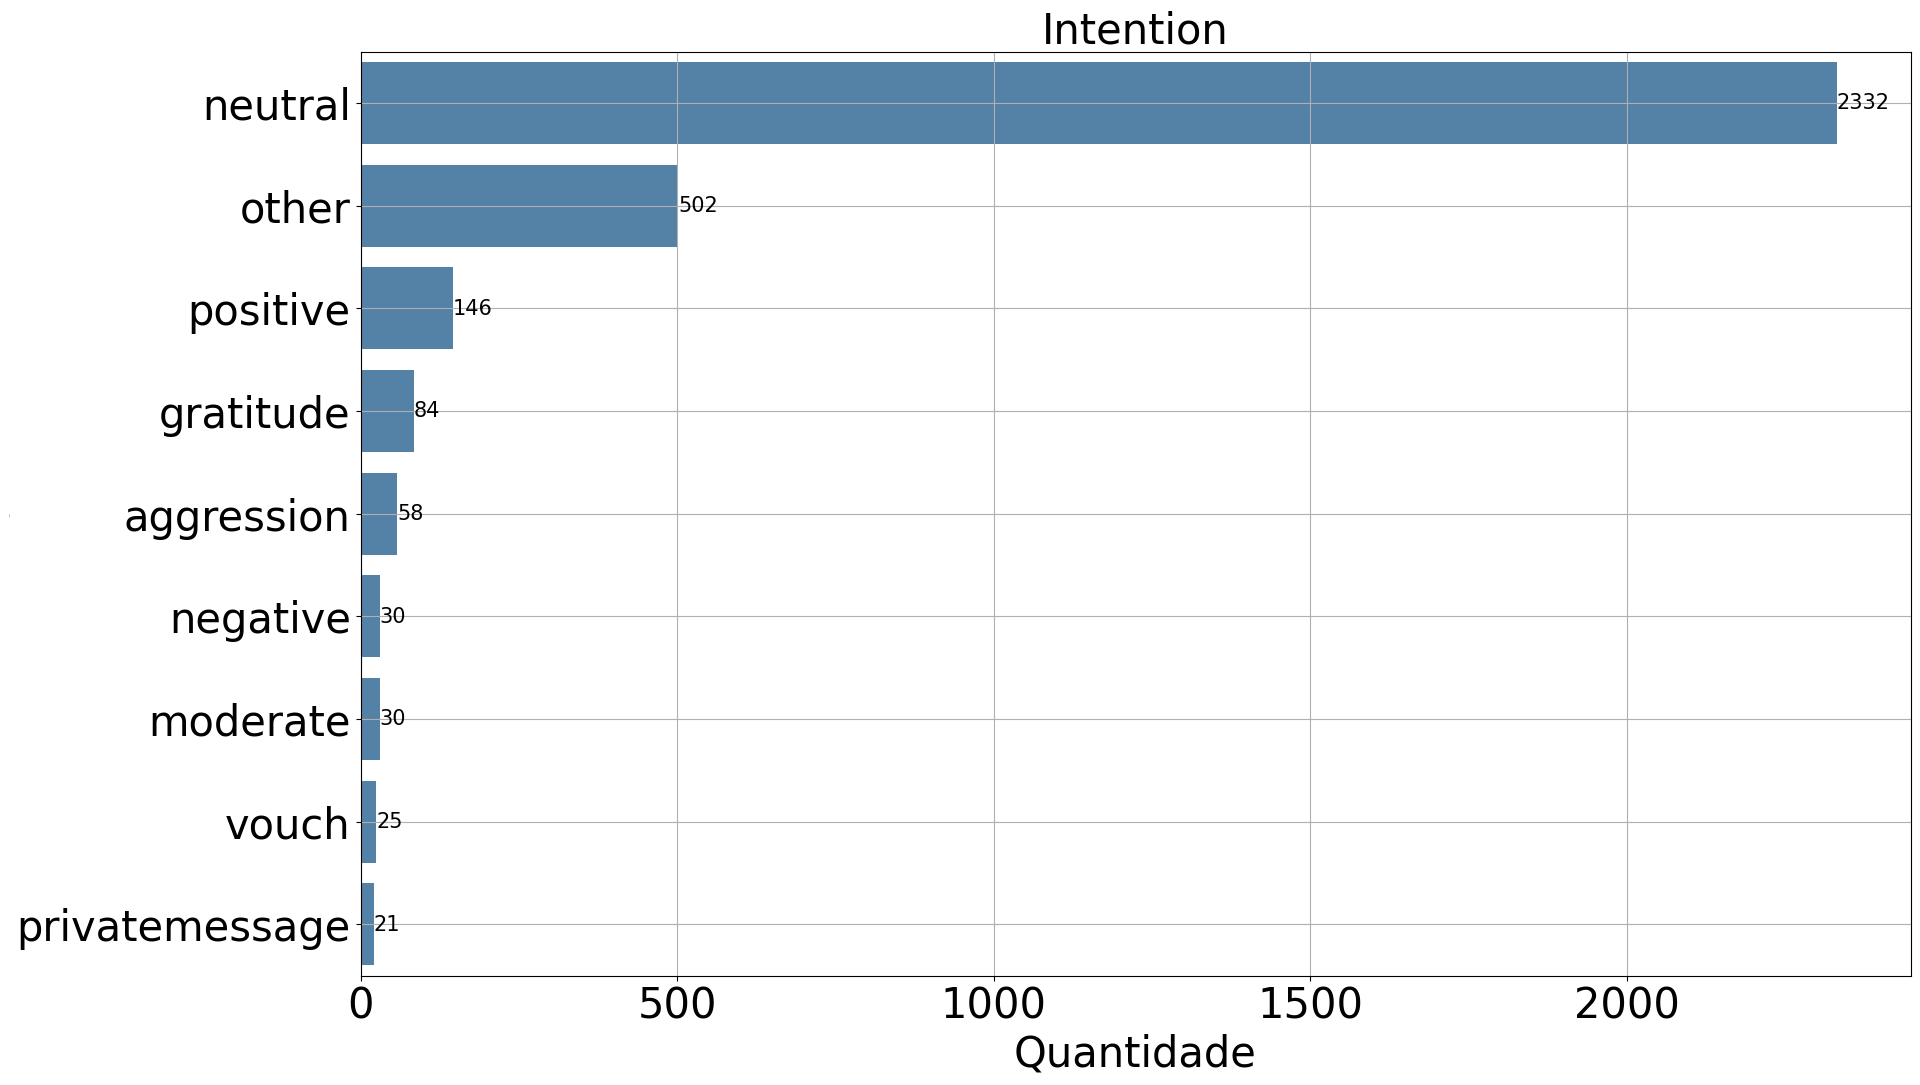

In [21]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["intention"],
                values=["thread_title"],
                aggfunc={
                    "thread_title":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Intention", fontsize=30)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantidade', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

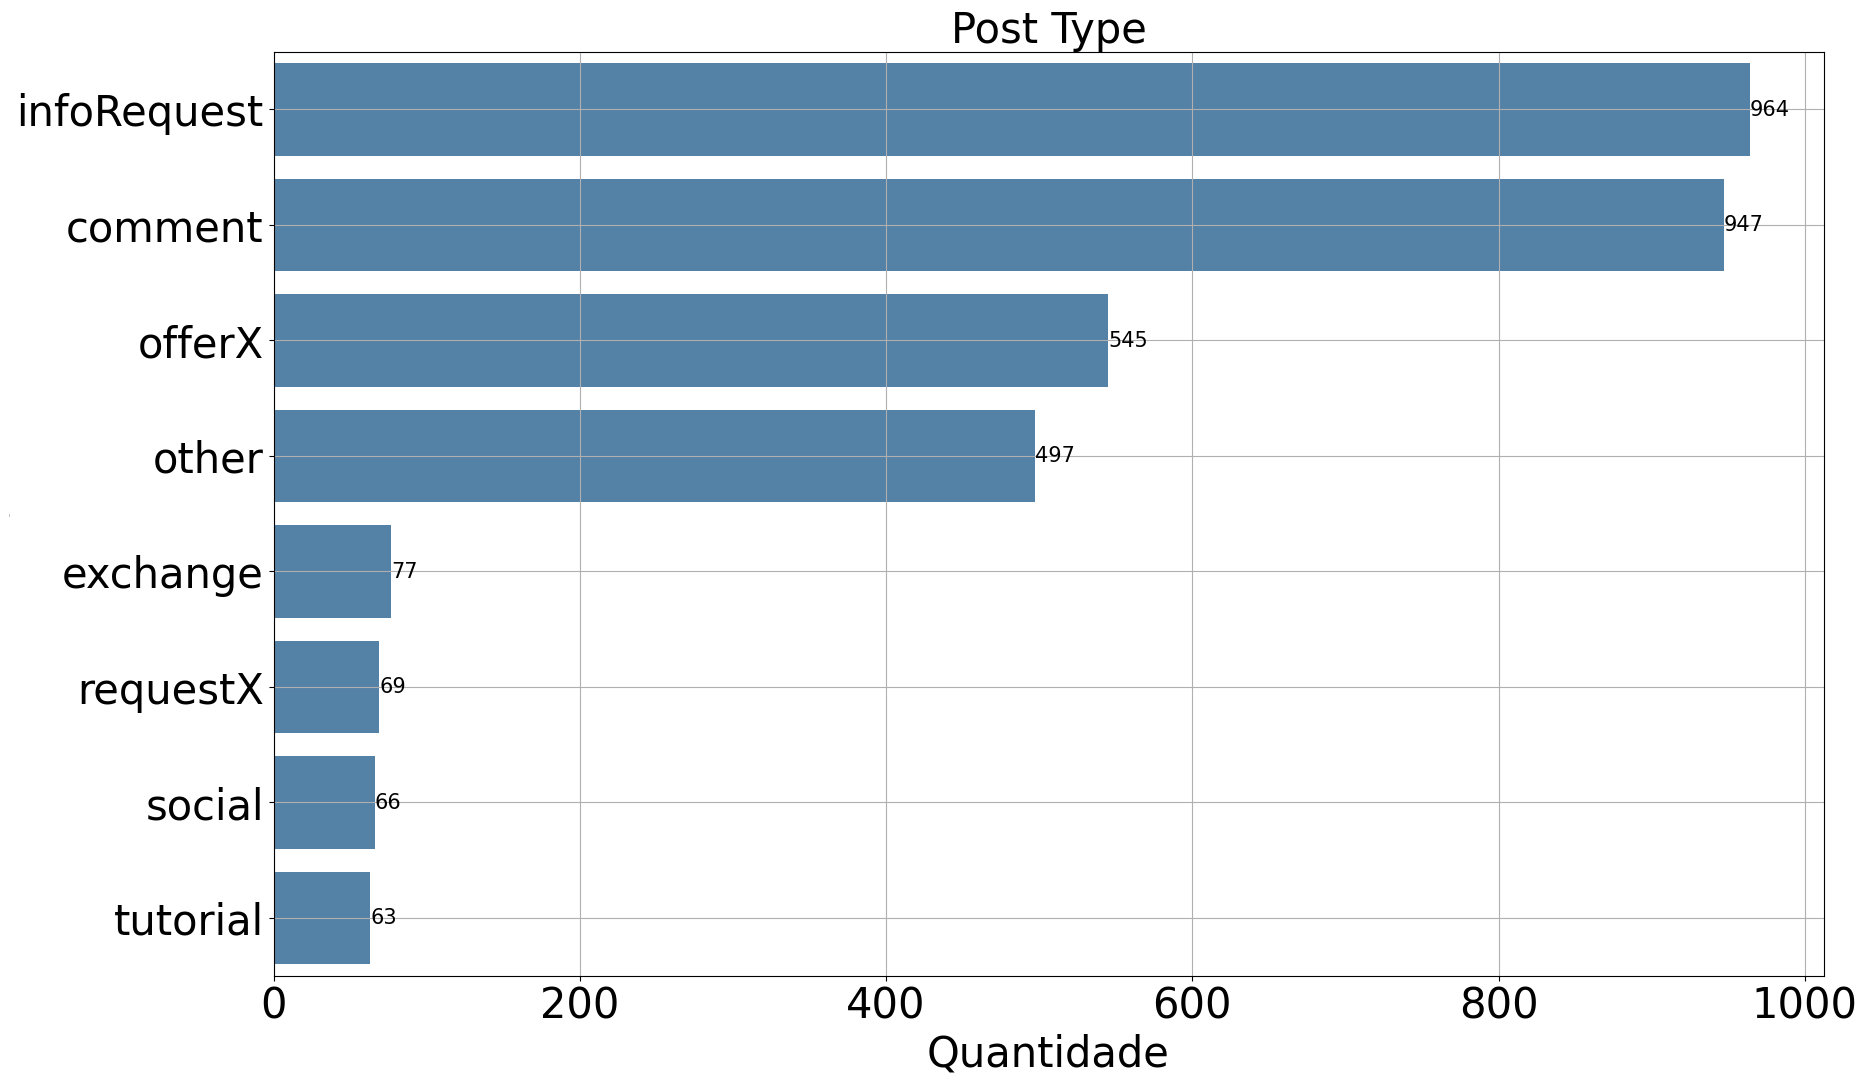

In [22]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["posttype"],
                values=["thread_title"],
                aggfunc={
                    "thread_title":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Post Type", fontsize=30)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantidade', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

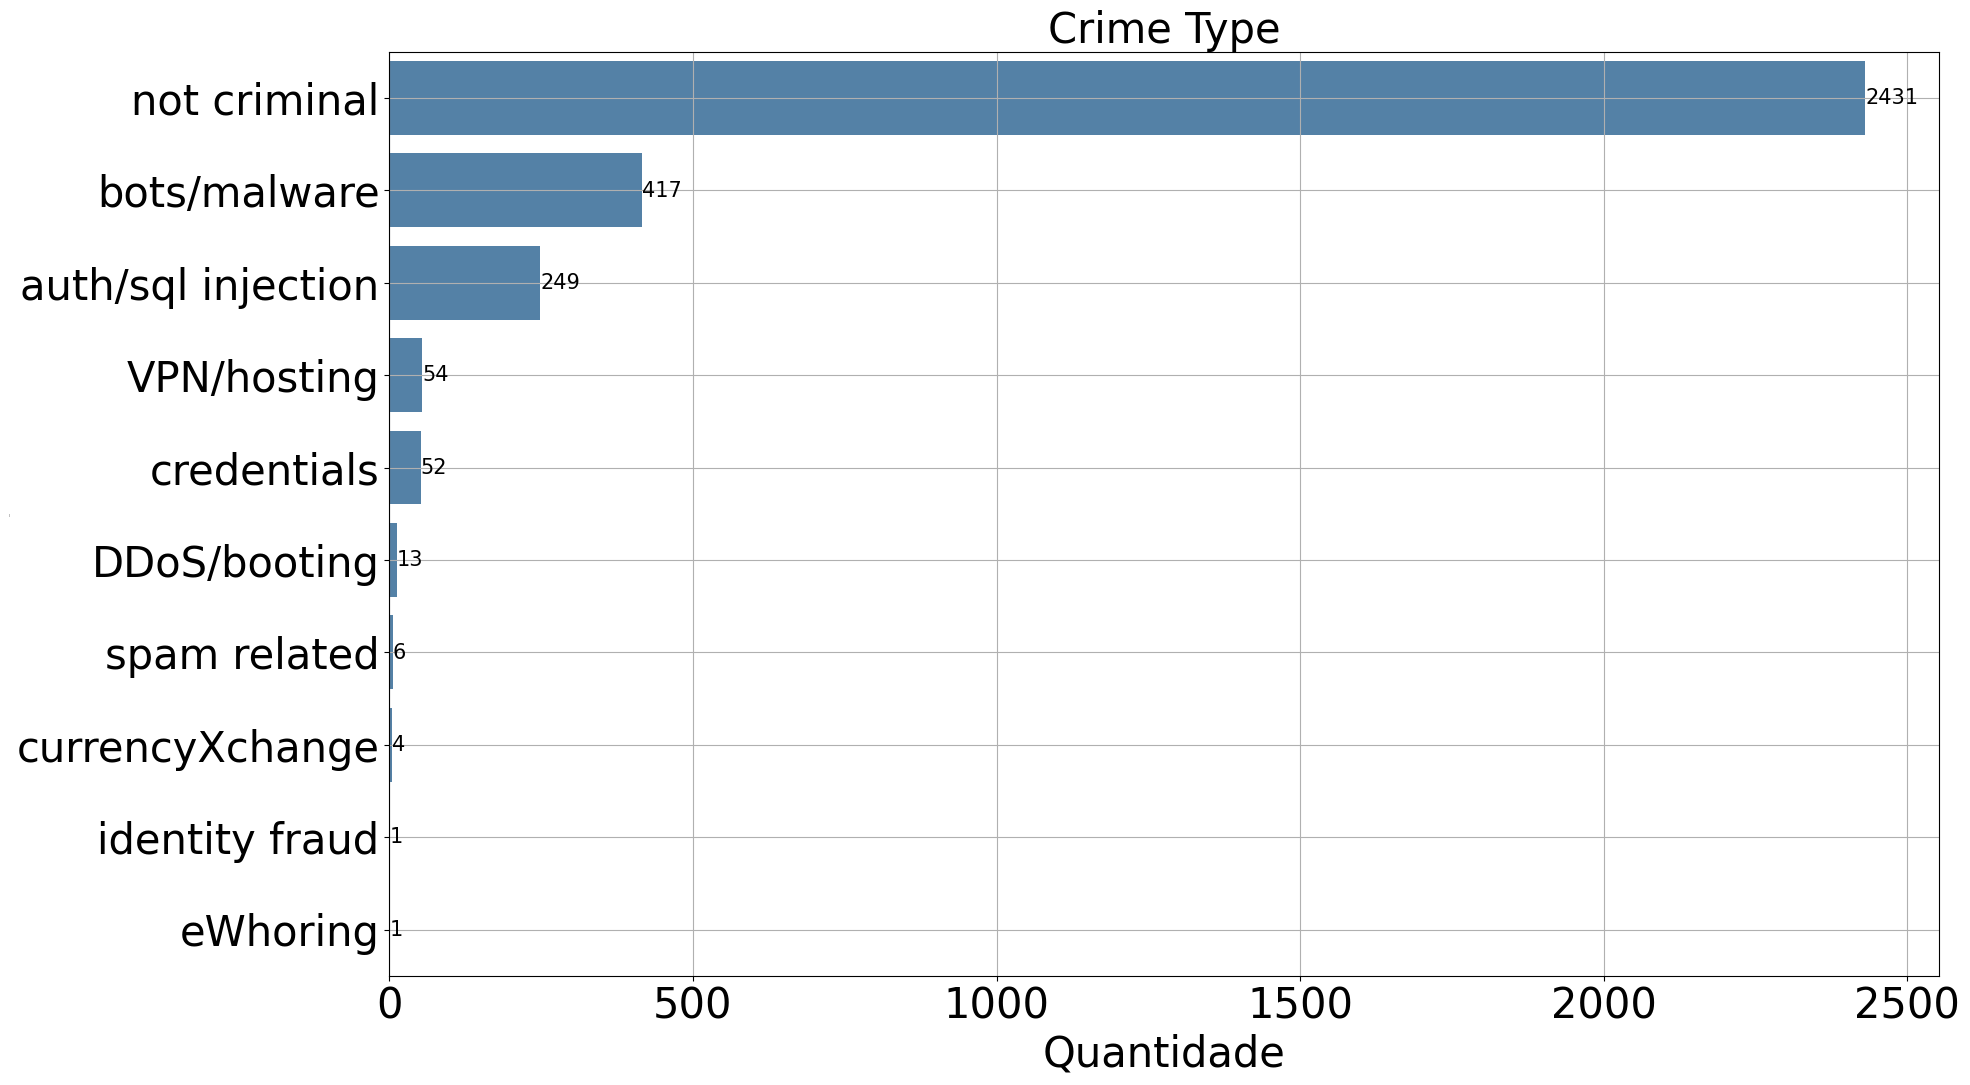

In [23]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["crimetype"],
                values=["thread_title"],
                aggfunc={
                    "thread_title":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Crime Type", fontsize=30)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantidade', fontsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=30)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [24]:
#classes_len = df["labels"].value_counts()
#df = df[ df["labels"].isin( list(classes_len[classes_len>2].index) ) ].copy()
#filter_df["labels"] = filter_df["crime_type"].apply(lambda x: x if x=="not criminal" else "criminal")
#filter_df["class"] = filter_df["labels"].astype('category').cat.codes

In [25]:
filter_df = filter_df[ ~ filter_df["crimetype"].isin(["currency exchange", "eWhoring"])].copy()
filter_df.shape

(3227, 29)

In [26]:
filter_df["intention_class"] = filter_df["intention"].astype('category').cat.codes
filter_df["chatgpt_intention_class"] = filter_df["chatgpt_intention"].astype('category').cat.codes

filter_df["posttype_class"] = filter_df["posttype"].astype('category').cat.codes
filter_df["chatgpt_posttype_class"] = filter_df["chatgpt_posttype"].astype('category').cat.codes

filter_df["crimetype_class"] = filter_df["crimetype"].astype('category').cat.codes
filter_df["chatgpt_crimetype_class"] = filter_df["chatgpt_crimetype"].astype('category').cat.codes

In [27]:
dict_features = {}
dict_features["content"] = filter_df["content"].values
dict_features["content_processed"] = filter_df["content_processed"].values

In [28]:
dict_features["intention"] = filter_df["intention"].values
dict_features["chatgpt_intention"] = filter_df["chatgpt_intention"].values

dict_features["posttype"] = filter_df["posttype"].values
dict_features["chatgpt_posttype"] = filter_df["chatgpt_posttype"].values

dict_features["crimetype"] = filter_df["crimetype"].values
dict_features["chatgpt_crimetype"] = filter_df["chatgpt_crimetype"].values

In [29]:
dict_features["intention_class"] = filter_df["intention_class"].values
dict_features["chatgpt_intention_class"] = filter_df["chatgpt_intention_class"].values

dict_features["posttype_class"] = filter_df["posttype_class"].values
dict_features["chatgpt_posttype_class"] = filter_df["chatgpt_posttype_class"].values

dict_features["crimetype_class"] = filter_df["crimetype_class"].values
dict_features["chatgpt_crimetype_class"] = filter_df["chatgpt_crimetype_class"].values

In [30]:
if cfg.PROCESS_TXT:
    documents = filter_df["content_processed"].values
    out_filename="_processed"
else:
    documents = filter_df["content"].values
    out_filename=""

In [31]:
text_input = [[word for word in doc.split()] for doc in documents]

In [32]:
# Create Dictionary
import gensim.corpora as corpora
id2word = corpora.Dictionary(text_input)

In [33]:
# Create Corpus: Term Document Frequency
corpus = [id2word.doc2bow(text) for text in text_input]

In [34]:
dict_features["corpus"] = corpus
dict_features["id2word"] = id2word

### TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfTransformer, TfidfVectorizer

In [36]:
tf_idf = TfidfVectorizer(max_features=num_words, # features: most occurring words
                         ngram_range=n_grams, # len of words context
                         sublinear_tf=True, # sublinear tf scaler
                         min_df=min_df, # min_df: a word repeated at least in 5 docs
                         max_df=max_df, # max_df: only those words that occur in a maximum of 90% of all the documents
                        )

In [37]:
%%time
X_tfidf = tf_idf.fit_transform(documents).toarray()
X_tfidf.shape, X_tfidf.dtype

CPU times: user 225 ms, sys: 3.95 ms, total: 229 ms
Wall time: 228 ms


((3227, 366), dtype('float64'))

In [38]:
X_tfidf[0][X_tfidf[0]>0]

array([0.03907325, 0.09543751, 0.05645315, 0.1649469 , 0.11432385,
       0.09803731, 0.10431398, 0.06583639, 0.09959772, 0.03749099,
       0.13422087, 0.1148817 , 0.07790045, 0.04877668, 0.07531529,
       0.12051323, 0.03426238, 0.10249329, 0.03502583, 0.07541053,
       0.08454574, 0.03793329, 0.07019444, 0.03562987, 0.03666309,
       0.09854551, 0.10495701, 0.10385762, 0.04780467, 0.0595177 ,
       0.03129465, 0.07111112, 0.08254391, 0.1621041 , 0.17671311,
       0.09853198, 0.08396362, 0.04914171, 0.04495826, 0.03913716,
       0.03407115, 0.06727264, 0.11590189, 0.06320557, 0.06750529,
       0.03959683, 0.17262783, 0.06827735, 0.07984615, 0.03711998,
       0.0675419 , 0.14006396, 0.07190345, 0.06780868, 0.04957496,
       0.07642795, 0.03279626, 0.03490118, 0.25267886, 0.02447287,
       0.04029412, 0.1963478 , 0.0334126 , 0.12510704, 0.0377096 ,
       0.07636357, 0.06010199, 0.06847064, 0.06704327, 0.03888403,
       0.15302694, 0.07182255, 0.08784662, 0.0623298 , 0.07350

In [39]:
dict_features["X_tfidf"] = X_tfidf
dict_features["tfidf_names"] = tf_idf.get_feature_names_out()

### Word2Vec - Bag of Words

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

In [41]:
cbow = CountVectorizer(max_features=num_words, # features: most occurring words
                       ngram_range=n_grams, # len of words context
                       min_df=min_df, # min_df: a word repeated at least in 5 docs
                       max_df=max_df, # max_df: only those words that occur in a maximum of 90% of all the documents
                      )

In [42]:
%%time
X_cbow = cbow.fit_transform(documents).toarray()
X_cbow.shape, X_cbow.dtype

CPU times: user 235 ms, sys: 1.97 ms, total: 237 ms
Wall time: 236 ms


((3227, 366), dtype('int64'))

In [43]:
X_cbow[0][X_cbow[0]>0]

array([  1,   6,   2,  27,  10,   9,   7,   2,   8,   1,  20,  11,   3,
         2,  15,  89,   1,   6,   1, 279,   7,   1,   3,   1,   1,   5,
         5,   5,   2,   2,   1,   4,  71,  35,  38,  21,   3,   3,   2,
         1,   1,   2,  14,   2,   2,   1,  87,   3,   3,   1,   5,  89,
         3,   3,   2,   3,   1,   1, 252,   1,   1, 174,   1,  14,   1,
         4,   2,   2,   2,   1,  28,   3,   4,   2,   3,   6,   1,   4,
         1,   2,   2,   5,   7,   1,   3,   2,   2,   9,   1,  22,   1,
         2,   8,   2,   2,   3,   2,   4,   1,   6,   1,  13,   2,   2,
         2,  21,   1,   1,   2,   3,  36,   1,   3,   5,   1,   4,   1,
         1,   2,   2,   1,   5,   3,   1,   2,  14,   1,   1,   2,   1,
        69,   3,  27,  31,   3,   1,   8,   4,   5])

In [44]:
dict_features["X_cbow"] = X_cbow
dict_features["cbow_names"] = cbow.get_feature_names_out()

### Word2Vec - Skip Gram

In [45]:
from gensim.models.phrases import Phrases

In [46]:
word_list_per_doc = [row.split() for row in documents]

In [47]:
phrases = Phrases(word_list_per_doc, min_count=30, progress_per=10000)

In [48]:
from gensim.models.phrases import Phraser

In [49]:
bigram = Phraser(phrases)

In [50]:
sentences = bigram[word_list_per_doc]

In [51]:
from gensim.models import Word2Vec

In [52]:
skip_gram = Word2Vec(min_count=20, # word frequency
                      vector_size=dim_vec, #output vector
                      window=15, # distance between words
                      sg=1, #Skip-Gram
                      sample=6e-5, 
                      alpha=0.03, 
                      min_alpha=0.0007, 
                      negative=20)

In [53]:
skip_gram.build_vocab(sentences, progress_per=10000)

In [54]:
skip_gram.train(sentences, total_examples=skip_gram.corpus_count, epochs=skip_gram.epochs)

(1648579, 3705375)

In [55]:
skip_gram.wv.most_similar('vulnerability', topn=20)

[('assigned', 0.7508888840675354),
 ('flaw', 0.7453818321228027),
 ('vulnerabilities', 0.7445595264434814),
 ('winrm', 0.7410554885864258),
 ('allow_remote', 0.7402152419090271),
 ('discovered', 0.7374778389930725),
 ('exposures', 0.7354086637496948),
 ('isc', 0.7313663959503174),
 ('execute_arbitrary', 0.7302859425544739),
 ('severe', 0.7288418412208557),
 ('maliciously', 0.7267000675201416),
 ('installations', 0.7261563539505005),
 ('leverage', 0.7259230613708496),
 ('according', 0.7258645296096802),
 ('bounty', 0.7234041094779968),
 ('exploited_wild', 0.7192263603210449),
 ('allow_attacker', 0.7171463370323181),
 ('exploited', 0.7145847082138062),
 ('vulnerable', 0.7135323882102966),
 ('exploitable', 0.7115181088447571)]

In [56]:
skip_gram.wv.most_similar('exploit', topn=20)

[('exploits', 0.7218960523605347),
 ('cve', 0.6747886538505554),
 ('shell', 0.5521252155303955),
 ('0day', 0.5502542853355408),
 ('hey_guys', 0.5455201268196106),
 ('download', 0.5296012759208679),
 ('trying', 0.5274590253829956),
 ('telegram', 0.5254215002059937),
 ('tiny', 0.5247077941894531),
 ('phpmailer', 0.5228427052497864),
 ('btw', 0.5227943062782288),
 ('edb', 0.5227192640304565),
 ('rce', 0.5200010538101196),
 ('versions', 0.5199586153030396),
 ('direction', 0.5176742076873779),
 ('coded', 0.5145425200462341),
 ('upload', 0.5144553184509277),
 ('dork', 0.5141109824180603),
 ('assuming', 0.5123714208602905),
 ('code', 0.512370228767395)]

In [57]:
skip_gram.wv.most_similar('fud', topn=20)

[('scammer', 0.8952614665031433),
 ('silent_doc', 0.8865658640861511),
 ('refud', 0.8814050555229187),
 ('silent', 0.8783644437789917),
 ('kapo', 0.8733786940574646),
 ('builder', 0.8643504977226257),
 ('macro_exploit', 0.8584732413291931),
 ('costs', 0.8529593348503113),
 ('scammed', 0.8513869047164917),
 ('ancalog', 0.8506166934967041),
 ('perfectly', 0.8461809158325195),
 ('legit', 0.8450777530670166),
 ('macro', 0.8440699577331543),
 ('scantime', 0.8393928408622742),
 ('undetected', 0.8341805338859558),
 ('add_skype', 0.826712965965271),
 ('trillium', 0.8254337310791016),
 ('bought', 0.8220380544662476),
 ('purchased', 0.820375382900238),
 ('tho', 0.8188960552215576)]

In [58]:
skip_gram.wv.most_similar('cve', topn=20)

[('exploits', 0.7336484789848328),
 ('exploit', 0.674788773059845),
 ('vulnerability', 0.6456701159477234),
 ('cves', 0.5690538287162781),
 ('folks', 0.5610188245773315),
 ('versions', 0.5522570610046387),
 ('credits', 0.5508518815040588),
 ('0day', 0.5480803847312927),
 ('searching', 0.5446552038192749),
 ('hey_guys', 0.5438982844352722),
 ('source', 0.5287306308746338),
 ('poc', 0.5276526808738708),
 ('btw', 0.527391254901886),
 ('showed', 0.5273448824882507),
 ('newer', 0.5267186164855957),
 ('exploiting', 0.5250199437141418),
 ('pocs', 0.522740364074707),
 ('guys', 0.5215469598770142),
 ('older', 0.5196585059165955),
 ('fresh', 0.518828272819519)]

In [59]:
skip_gram.wv.most_similar('poc', topn=20)

[('pocs', 0.8008208274841309),
 ('github', 0.7344640493392944),
 ('btw', 0.7332187294960022),
 ('folks', 0.7155275940895081),
 ('helpful', 0.7147320508956909),
 ('direction', 0.7116415500640869),
 ('yeah', 0.7079231142997742),
 ('anybody', 0.706382691860199),
 ('cvedetails', 0.7022886872291565),
 ('curious', 0.7013147473335266),
 ('cheers', 0.6963610053062439),
 ('wonder', 0.693903923034668),
 ('helping', 0.6937776803970337),
 ('nvd_nist', 0.690639078617096),
 ('bunch', 0.687473475933075),
 ('proof_concept', 0.6849637627601624),
 ('isc', 0.6813796758651733),
 ('posted', 0.6799282431602478),
 ('reproduce', 0.6797550916671753),
 ('appreciated', 0.6781849265098572)]

### Doc2Vec

In [60]:
from gensim.test.utils import common_texts
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [61]:
sentences_doc = [TaggedDocument(doc, [i]) for i, doc in enumerate(documents)]

In [62]:
doc2vec = Doc2Vec(vector_size=dim_vec, # output vector
                  min_count=min_count, # word frequency
                  window=window, # distance between words
                  sample=sample, # words with frequency lower than this value, are ignored
                  alpha=alpha, 
                  min_alpha=min_alpha, 
                  negative=negative # noisy words
                 )

In [63]:
doc2vec.build_vocab(sentences_doc, progress_per=10000)

In [64]:
doc2vec.train(sentences_doc, total_examples=doc2vec.corpus_count, epochs=doc2vec.epochs)

In [65]:
X_doc2vec = np.array([doc2vec.infer_vector([doc]) for doc in documents])
X_doc2vec.shape, X_doc2vec.dtype

((3227, 5000), dtype('float32'))

In [66]:
dict_features["X_doc2vec"] = X_doc2vec

In [67]:
for k in dict_features.keys():
    print(k, len(dict_features[k]))

content 3227
content_processed 3227
intention 3227
chatgpt_intention 3227
posttype 3227
chatgpt_posttype 3227
crimetype 3227
chatgpt_crimetype 3227
intention_class 3227
chatgpt_intention_class 3227
posttype_class 3227
chatgpt_posttype_class 3227
crimetype_class 3227
chatgpt_crimetype_class 3227
corpus 3227
id2word 58591
X_tfidf 3227
tfidf_names 366
X_cbow 3227
cbow_names 366
X_doc2vec 3227


### Saving Files

In [68]:
import pickle
# create a binary pickle file 
file_ = open(f"{FEATURES_PATH}metadata{out_filename}.pkl","wb")

# write the python object (dict) to pickle file
pickle.dump(dict_features, file_)

# close file
file_.close()